# FoodVision Mini 🍕🥩🍣

A small CNN (TinyVGG) that classifies images of **pizza, steak and sushi**.

This is a learning project following the "PyTorch for Deep Learning" custom
datasets material — built to understand how a real image classification
pipeline is put together (data -> model -> train -> predict), then split
into reusable scripts under `going_modular/` instead of one giant notebook.

**Pipeline:** download data -> load into `DataLoader`s -> build a TinyVGG
CNN -> train it -> check loss/accuracy curves -> predict on a custom image.


In [4]:
import torch
from torch import nn
from torchvision import transforms
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cpu'

In [5]:
import data_setup, model_builder, engine, utils, predict

## 1. Get the data

Small subset of Food101 — 3 classes, ~75 training / 25 test images per class.
Starting small so experiments are fast.

In [6]:
image_path = data_setup.download_data(
    url="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
    destination="pizza_steak_sushi",
)

train_dir = image_path / "train"
test_dir = image_path / "test"

utils.walk_thru_dir(image_path)


data\pizza_steak_sushi already exists, skipping download.
2 directories, 0 images in 'data\pizza_steak_sushi'
3 directories, 0 images in 'data\pizza_steak_sushi\test'
0 directories, 25 images in 'data\pizza_steak_sushi\test\pizza'
0 directories, 19 images in 'data\pizza_steak_sushi\test\steak'
0 directories, 31 images in 'data\pizza_steak_sushi\test\sushi'
3 directories, 0 images in 'data\pizza_steak_sushi\train'
0 directories, 78 images in 'data\pizza_steak_sushi\train\pizza'
0 directories, 75 images in 'data\pizza_steak_sushi\train\steak'
0 directories, 72 images in 'data\pizza_steak_sushi\train\sushi'


## 2. Turn data into DataLoaders

Resize every image to 64x64 and turn it into a tensor. Small image size =
faster to train, which is what we want while experimenting.

In [7]:
data_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=data_transform,
    batch_size=32,
)

class_names


['pizza', 'steak', 'sushi']

## 3. Build the model

`TinyVGG` — a small CNN with 2 conv blocks + a linear classifier.
See `going_modular/model_builder.py` for the architecture itself.

In [8]:
torch.manual_seed(42)
model = model_builder.TinyVGG(
    input_shape=3,          # RGB images
    hidden_units=10,        # keep it small on purpose
    output_shape=len(class_names),
).to(device)

model


TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

### Sanity check: one forward pass

Before training anything, just check the model runs and outputs the
shape we expect: `[batch_size, num_classes]`.

In [9]:
img_batch, label_batch = next(iter(train_dataloader))
model.eval()
with torch.inference_mode():
    pred = model(img_batch.to(device))

print(f"Output shape: {pred.shape}")


c:\Users\Acer\Holy Grail\venv\Lib\site-packages\torch\utils\data\dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Output shape: torch.Size([32, 3])


## 4. Train the model

Standard setup: CrossEntropyLoss + Adam. `engine.train()` runs the
train/test loop for however many epochs and hands back a results dict.

In [10]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

torch.manual_seed(42)
results = engine.train(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=5,
    device=device,
)


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1071 | train_acc: 0.2500 | test_loss: 1.1061 | test_acc: 0.2604
Epoch: 2 | train_loss: 1.0784 | train_acc: 0.4258 | test_loss: 1.1397 | test_acc: 0.2604
Epoch: 3 | train_loss: 1.0804 | train_acc: 0.4258 | test_loss: 1.1702 | test_acc: 0.2604
Epoch: 4 | train_loss: 1.1284 | train_acc: 0.3047 | test_loss: 1.1596 | test_acc: 0.2604
Epoch: 5 | train_loss: 1.0891 | train_acc: 0.4258 | test_loss: 1.1444 | test_acc: 0.2604


## 5. Check the results

Loss should be going down, accuracy should be going up. With this little
data and this small a model, don't expect miracles — the point here was
to understand the pipeline, not to win a Kaggle competition.

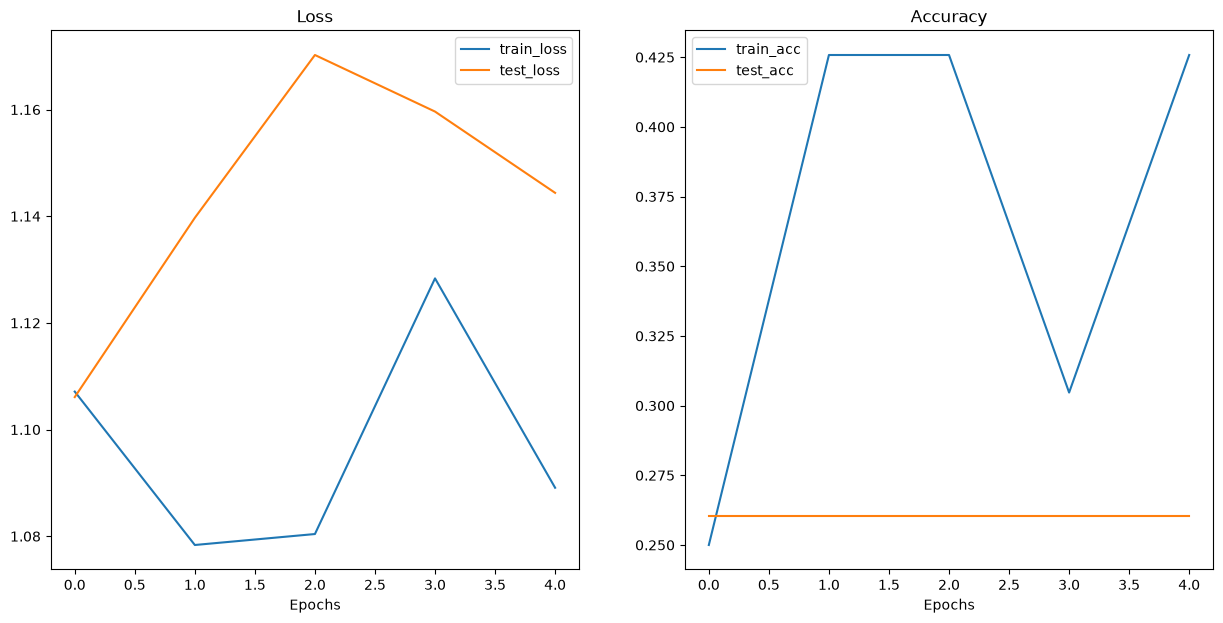

In [11]:
utils.plot_loss_curves(results)


## 6. Predict on a custom image

The real test: grab a photo that isn't in the dataset at all and see what
the model thinks it is.

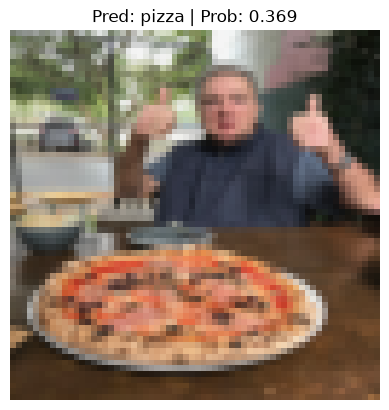

In [ ]:
import requests
from pathlib import Path

custom_image_path = Path("data") / "04-pizza-dad.jpeg"

if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        request = requests.get(
            "https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg"
        )
        f.write(request.content)

predict.pred_and_plot_image(
    model=model,
    image_path=custom_image_path,
    class_names=class_names,
    transform=transforms.Resize((64,64)),
    device=device,
)


## Notes / things I learned

- `ImageFolder` + `DataLoader` is the quickest way to get folder-of-images
  data into PyTorch — no need to write a custom `Dataset` unless you need
  something ImageFolder can't do.
- TinyVGG is basically: (conv -> relu -> conv -> relu -> maxpool) x2, then
  flatten -> linear. Two conv blocks is enough to learn *something* on a
  tiny dataset like this.
- Overfitting shows up fast with this little data — train accuracy climbs
  way faster than test accuracy.
- Splitting reusable code into `going_modular/` scripts makes it way easier
  to reuse this pipeline on a different dataset later.
